In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df = sns.load_dataset("iris")

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
from sklearn.preprocessing import LabelEncoder

In [5]:
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])

In [6]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
df.sample(
    5
)

,sepal_length,sepal_width,petal_length,petal_width,species
94,5.6,2.7,4.2,1.3,1
88,5.6,3.0,4.1,1.3,1
119,6.0,2.2,5.0,1.5,2
29,4.7,3.2,1.6,0.2,0
6,4.6,3.4,1.4,0.3,0


In [8]:
df = df[df['species'] != 0][[ 'sepal_width','petal_length', 'species']]

In [9]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [10]:
df.shape

(100, 3)

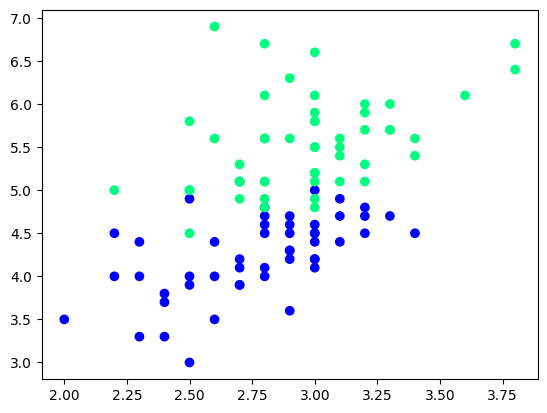

In [11]:
import matplotlib.pyplot as plt

plt.scatter(df['sepal_width'], df['petal_length'], c=df['species'],cmap='winter')

In [13]:
# taking only 10 rows for training

df_train = df.iloc[:60, :].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [14]:
df_train

,sepal_width,petal_length,species
57,2.4,3.3,1
94,2.7,4.2,1
78,2.9,4.5,1
101,2.7,5.1,2
52,3.1,4.9,1
106,2.5,4.5,2
102,3.0,5.9,2
76,2.8,4.8,1
79,2.6,3.5,1
62,2.2,4.0,1


In [15]:
df_val

,sepal_width,petal_length,species
118,2.6,6.9,2
123,2.7,4.9,2
120,3.2,5.7,2
126,2.8,4.8,2
127,3.0,4.9,2


In [16]:
df_test

,sepal_width,petal_length,species
142,2.7,5.1,2
141,3.1,5.1,2
147,3.0,5.2,2
145,3.0,5.2,2
143,3.2,5.9,2


In [20]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

# Case 1: Bagging

In [36]:
# Data for tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2].values
y = df_bag.iloc[:,-1].values

df_bag

,sepal_width,petal_length,species
78,2.9,4.5,1
52,3.1,4.9,1
62,2.2,4.0,1
94,2.7,4.2,1
94,2.7,4.2,1
101,2.7,5.1,2
57,2.4,3.3,1
76,2.8,4.8,1


In [37]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [38]:
dt_bag1 = DecisionTreeClassifier()

In [39]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X, y.astype(np.integer), clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print("Accuracy", accuracy_score(y_test,y_pred))

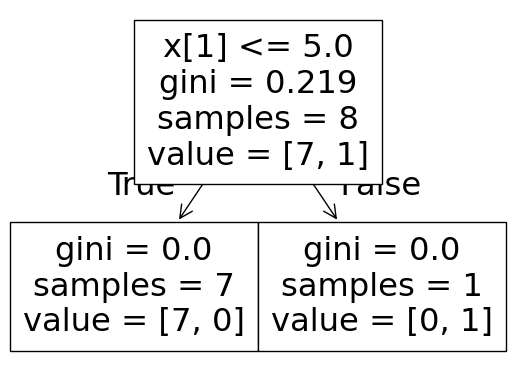

Accuracy 0.4


/var/folders/55/mhy5dtxs1g11qqd33n2hv53h0000gn/T/ipykernel_38462/3571452113.py:5: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(X, y.astype(np.integer), clf=clf, legend=2)


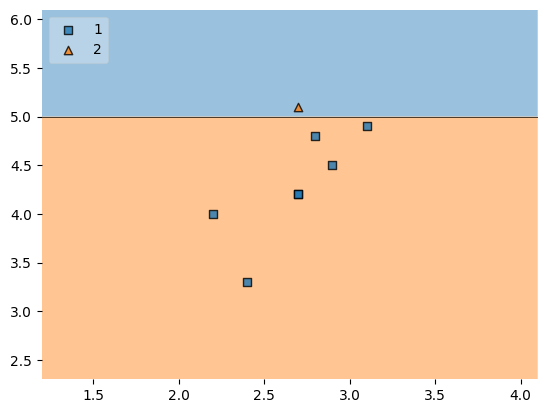

In [40]:
evaluate(dt_bag1,X,y)

In [41]:
# Data for tree 2
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2].values
y = df_bag.iloc[:,-1].values

df_bag

,sepal_width,petal_length,species
62,2.2,4.0,1
94,2.7,4.2,1
78,2.9,4.5,1
76,2.8,4.8,1
101,2.7,5.1,2
102,3.0,5.9,2
79,2.6,3.5,1
76,2.8,4.8,1


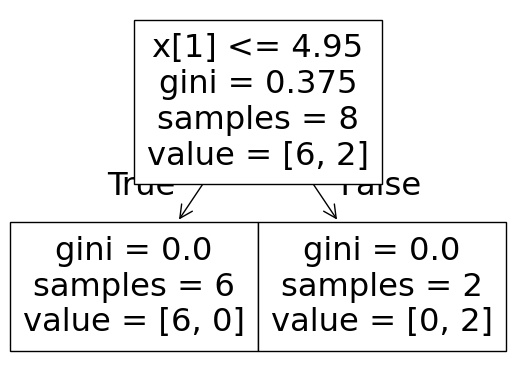

Accuracy 0.4


/var/folders/55/mhy5dtxs1g11qqd33n2hv53h0000gn/T/ipykernel_38462/3571452113.py:5: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(X, y.astype(np.integer), clf=clf, legend=2)


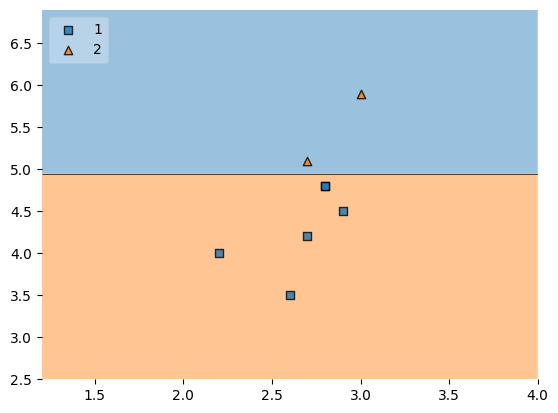

In [42]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [43]:
# Data for tree 3
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2].values
y = df_bag.iloc[:,-1].values

df_bag

,sepal_width,petal_length,species
57,2.4,3.3,1
102,3.0,5.9,2
57,2.4,3.3,1
102,3.0,5.9,2
101,2.7,5.1,2
52,3.1,4.9,1
78,2.9,4.5,1
101,2.7,5.1,2


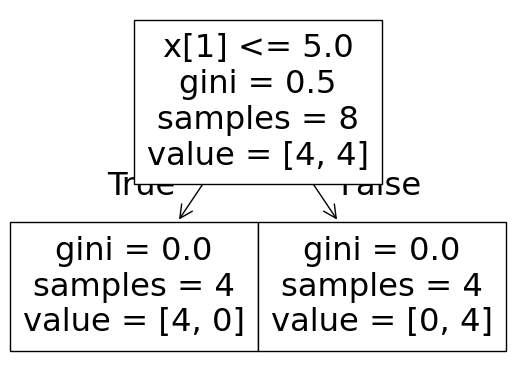

Accuracy 0.4


/var/folders/55/mhy5dtxs1g11qqd33n2hv53h0000gn/T/ipykernel_38462/3571452113.py:5: DeprecationWarning: Converting `np.integer` or `np.signedinteger` to a dtype is deprecated. The current result is `np.dtype(np.int_)` which is not strictly correct. Note that the result depends on the system. To ensure stable results use may want to use `np.int64` or `np.int32`.
  plot_decision_regions(X, y.astype(np.integer), clf=clf, legend=2)


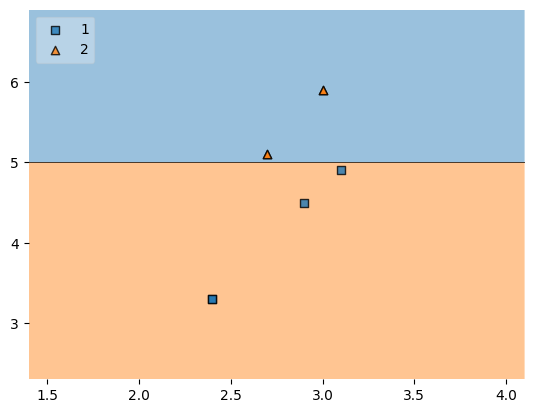

In [44]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

# Predict

In [45]:
df_test

,sepal_width,petal_length,species
142,2.7,5.1,2
141,3.1,5.1,2
147,3.0,5.2,2
145,3.0,5.2,2
143,3.2,5.9,2


In [46]:
print("Predictior 1: ",dt_bag1.predict(np.array([2.7,5.1]).reshape(1,2)))
print("Predictior 2: ",dt_bag2.predict(np.array([2.7,5.1]).reshape(1,2)))
print("Predictior 3: ",dt_bag3.predict(np.array([2.7,5.1]).reshape(1,2)))

Predictior 1:  [2]
Predictior 2:  [2]
Predictior 3:  [2]


# Types of Bagging

In [48]:
# 1. Pasting
# In pasting we do row sampling without replacement 
df_train

,sepal_width,petal_length,species
57,2.4,3.3,1
94,2.7,4.2,1
78,2.9,4.5,1
101,2.7,5.1,2
52,3.1,4.9,1
106,2.5,4.5,2
102,3.0,5.9,2
76,2.8,4.8,1
79,2.6,3.5,1
62,2.2,4.0,1


In [49]:
df_train.sample(8,replace=False)

,sepal_width,petal_length,species
57,2.4,3.3,1
52,3.1,4.9,1
102,3.0,5.9,2
106,2.5,4.5,2
101,2.7,5.1,2
76,2.8,4.8,1
94,2.7,4.2,1
78,2.9,4.5,1


In [50]:
# 2. Random Subspaces
# here we do column sampling with replacement
df1 = sns.load_dataset("iris")
df1 = df1.sample(10)

In [51]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
87,6.3,2.3,4.4,1.3,versicolor
102,7.1,3.0,5.9,2.1,virginica
55,5.7,2.8,4.5,1.3,versicolor
46,5.1,3.8,1.6,0.2,setosa
83,6.0,2.7,5.1,1.6,versicolor
139,6.9,3.1,5.4,2.1,virginica
10,5.4,3.7,1.5,0.2,setosa
53,5.5,2.3,4.0,1.3,versicolor
118,7.7,2.6,6.9,2.3,virginica
63,6.1,2.9,4.7,1.4,versicolor


In [52]:
df1.sample(2,axis=1,replace=True)

,petal_length,petal_width
87,4.4,1.3
102,5.9,2.1
55,4.5,1.3
46,1.6,0.2
83,5.1,1.6
139,5.4,2.1
10,1.5,0.2
53,4.0,1.3
118,6.9,2.3
63,4.7,1.4


In [53]:
# 3. Random Patches
# here we do row and column sampling with replacement

df1

,sepal_length,sepal_width,petal_length,petal_width,species
87,6.3,2.3,4.4,1.3,versicolor
102,7.1,3.0,5.9,2.1,virginica
55,5.7,2.8,4.5,1.3,versicolor
46,5.1,3.8,1.6,0.2,setosa
83,6.0,2.7,5.1,1.6,versicolor
139,6.9,3.1,5.4,2.1,virginica
10,5.4,3.7,1.5,0.2,setosa
53,5.5,2.3,4.0,1.3,versicolor
118,7.7,2.6,6.9,2.3,virginica
63,6.1,2.9,4.7,1.4,versicolor


In [55]:
df1.sample(8,replace=True).sample(2,axis=1,replace=True)

,petal_length,petal_length
118,6.9,6.9
139,5.4,5.4
118,6.9,6.9
46,1.6,1.6
139,5.4,5.4
102,5.9,5.9
118,6.9,6.9
55,4.5,4.5
